# 1 — Analyze

Exploratory analysis of QBacMet data and circuit features. Generates paper figures for Section 6.

**Run after** `0_preprocess.ipynb`.

In [28]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

# IEEE-paper PDF quality (same as 2_model.ipynb).
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
C = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
     "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"]
COL1_W = 3.5    # IEEE single-column width (in)
COL2_W = 7.16   # IEEE double-column width (in)

BASE = Path("/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related")
# Save figures locally to MQBac/images/. Copy whichever you want into the
# paper at meta_backend_paper/meta_backend_qfw/images/ manually.
IMG = Path("images")
IMG.mkdir(parents=True, exist_ok=True)

# Load data
qf = pd.read_csv("final_data/qbacmet_flat.csv")
rt = pd.read_csv("final_data/estimate_runtime_df.csv")
print(f"qbacmet_flat:       {qf.shape}")
print(f"estimate_runtime:   {rt.shape}")


qbacmet_flat:       (1222, 76)
estimate_runtime:   (3500, 80)


## 1. Depth Inflation Analysis

Compare pre-transpile (`algo_depth`) vs post-transpile (`hw_circ_depth`) across benchmarks and backends. Only hardware backends have transpile data.

In [29]:
# Keep rows that have both algo and hw depth (hardware backends)
hw = qf.dropna(subset=["algo_depth", "hw_circ_depth"]).copy()
hw["depth_ratio"] = hw["hw_circ_depth"] / hw["algo_depth"]
hw["twoq_ratio"]  = hw["hw_circ_num_2q_gates"] / hw["algo_num_2q_gates"].replace(0, np.nan)
print(f"Rows with transpile data: {len(hw)}")
print(f"Benchmarks: {sorted(hw['arg_benchmark_name'].unique())}")
print(f"Backends:   {sorted(hw['arg_sub_backend'].unique())}")


Rows with transpile data: 1183
Benchmarks: ['bit_code', 'ghz', 'ham', 'hhl', 'mermin_bell', 'phase_code', 'tfim']
Backends:   ['aria-1', 'aria-2', 'forte-1', 'forte-enterprise-1', 'harmony', 'ibm_miami', 'ibm_torino', 'ideal', 'simulator']


Saved images/depth_inflation_heatmap.pdf


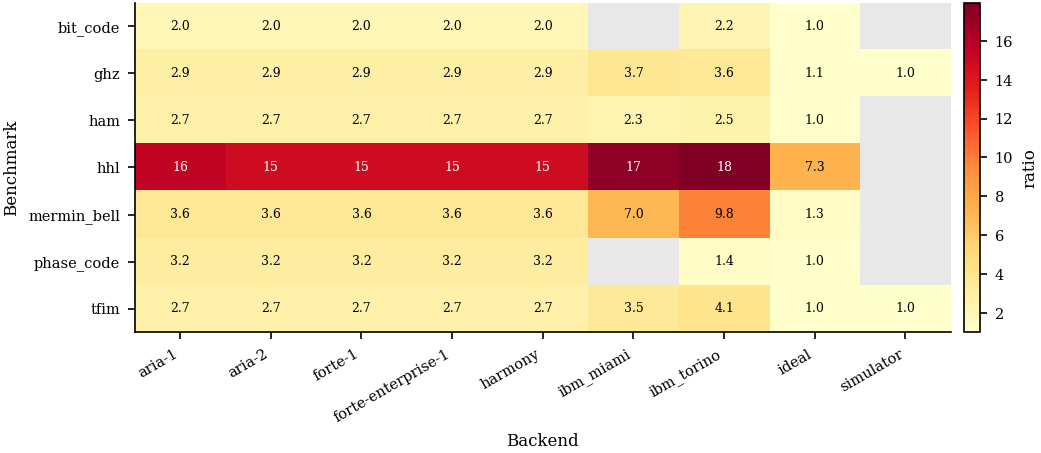

In [38]:
# Depth-inflation heatmap (benchmark x backend) — paper side-figure.
pivot = hw.pivot_table(
    index="arg_benchmark_name", columns="arg_sub_backend",
    values="depth_ratio", aggfunc="mean"
)

# Mask NaN cells so they render distinctly (light gray) rather than blank.
data = pivot.values
masked = np.ma.masked_invalid(data)
cmap = plt.get_cmap("YlOrRd").copy()
cmap.set_bad(color="#e8e8e8")

# Double-column width: more breathing room for cell text and tick labels.
fig, ax = plt.subplots(figsize=(COL2_W, COL2_W * 0.45))
vmin = float(np.nanmin(data))
vmax = float(np.nanmax(data))
im = ax.imshow(masked, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)

ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=7)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(pivot.index, fontsize=7)

# Annotate cells with values; format adapts to magnitude to prevent overlap.
thresh = vmin + 0.55 * (vmax - vmin)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = data[i, j]
        if np.isnan(v):
            continue
        txt = f"{v:.0f}" if v >= 10 else f"{v:.1f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=6,
                color="white" if v > thresh else "black")

ax.set_xlabel("Backend")
ax.set_ylabel("Benchmark")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.015, label="ratio")
plt.tight_layout()
fig.savefig(IMG / "depth_inflation_heatmap.pdf")
print(f"Saved {IMG / 'depth_inflation_heatmap.pdf'}")
plt.show()


Saved images/depth_inflation_scatter.pdf


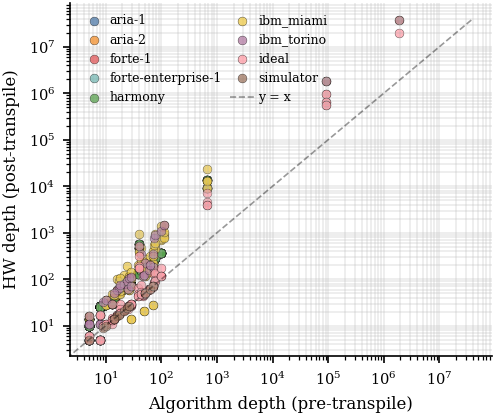

In [39]:
# Depth-inflation scatter (algo_depth vs hw_circ_depth, colored by backend).
# Side-figure: motivates the heatmap by showing per-circuit spread.
fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.85))
backends = sorted(hw["arg_sub_backend"].dropna().unique())
for i, be in enumerate(backends):
    sub = hw[hw["arg_sub_backend"] == be]
    ax.scatter(sub["algo_depth"], sub["hw_circ_depth"],
               label=be, color=C[i % len(C)], s=18, alpha=0.75,
               edgecolors="black", linewidths=0.2)
mx = max(hw["algo_depth"].max(), hw["hw_circ_depth"].max()) * 1.05
ax.plot([0, mx], [0, mx], "k--", alpha=0.4, lw=0.8, label="y = x")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Algorithm depth (pre-transpile)")
ax.set_ylabel("HW depth (post-transpile)")
ax.legend(loc="upper left", ncol=2, frameon=False, fontsize=6,
          handletextpad=0.3, columnspacing=0.6)
ax.grid(True, which="both", alpha=0.25)
plt.tight_layout()
fig.savefig(IMG / "depth_inflation_scatter.pdf")
print(f"Saved {IMG / 'depth_inflation_scatter.pdf'}")
plt.show()


## 2. Transpile Overhead

In [32]:
# ── Commented out: not used in paper (Apr 2026). Kept for reference. ──
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ax = axes[0]
# groups_be = [hw[hw["arg_sub_backend"] == b]["depth_ratio"].dropna()
#              for b in backends]
# bp = ax.boxplot(groups_be, labels=backends, patch_artist=True)
# for patch, c in zip(bp["boxes"], C):
#     patch.set_facecolor(c); patch.set_alpha(0.7)
# ax.axhline(1.0, color="k", ls="--", alpha=0.4)
# ax.set_ylabel("Depth ratio (HW / Algo)", fontsize=11)
# ax.set_title("Depth Inflation by Backend", fontsize=12)
# ax.tick_params(axis="x", rotation=30)
# ax.grid(True, axis="y", alpha=0.3)
# ax = axes[1]
# benches = sorted(hw["arg_benchmark_name"].unique())
# groups_bm = [hw[hw["arg_benchmark_name"] == b]["depth_ratio"].dropna()
#              for b in benches]
# bp = ax.boxplot(groups_bm, labels=benches, patch_artist=True)
# for patch, c in zip(bp["boxes"], C):
#     patch.set_facecolor(c); patch.set_alpha(0.7)
# ax.axhline(1.0, color="k", ls="--", alpha=0.4)
# ax.set_ylabel("Depth ratio", fontsize=11)
# ax.set_title("Depth Inflation by Benchmark", fontsize=12)
# ax.tick_params(axis="x", rotation=30)
# ax.grid(True, axis="y", alpha=0.3)
# plt.tight_layout()
# fig.savefig(IMG / "transpile_boxplots.pdf")
# plt.show()
print("[skipped] transpile_boxplots (not used in paper)")


[skipped] transpile_boxplots (not used in paper)


Saved images/gate_count_distributions.pdf


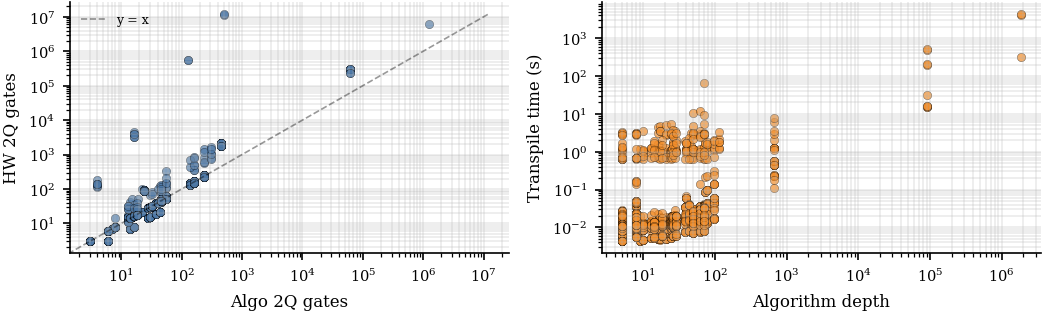

In [40]:
# 2Q-gate inflation + transpile-cost scaling — twin motivation panel.
fig, axes = plt.subplots(1, 2, figsize=(COL2_W, COL2_W * 0.32))

# (a) Algo 2Q gates vs HW 2Q gates
ax = axes[0]
g2q = hw.dropna(subset=["algo_num_2q_gates", "hw_circ_num_2q_gates"])
ax.scatter(g2q["algo_num_2q_gates"], g2q["hw_circ_num_2q_gates"],
           c=C[0], s=16, alpha=0.7, edgecolors="black", linewidths=0.2)
mx = max(g2q["algo_num_2q_gates"].max(),
         g2q["hw_circ_num_2q_gates"].max()) * 1.05
ax.plot([0, mx], [0, mx], "k--", alpha=0.4, lw=0.8, label="y = x")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Algo 2Q gates")
ax.set_ylabel("HW 2Q gates")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False, fontsize=6, loc="upper left")

# (b) Transpile time vs algorithm depth
ax = axes[1]
tp = hw.dropna(subset=["algo_depth", "exec_transpile_time"])
ax.scatter(tp["algo_depth"], tp["exec_transpile_time"],
           c=C[1], s=16, alpha=0.7, edgecolors="black", linewidths=0.2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Algorithm depth")
ax.set_ylabel("Transpile time (s)")
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
fig.savefig(IMG / "gate_count_distributions.pdf")
print(f"Saved {IMG / 'gate_count_distributions.pdf'}")
plt.show()


## 3. Backend Runtime Comparison

In [34]:
# ── Commented out: not used in paper (Apr 2026). Kept for reference. ──
# fig, ax = plt.subplots(figsize=(10, 5))
# be_order = rt.groupby("backend")["runtime_ms"].median().sort_values().index
# groups = [rt[rt["backend"] == b]["runtime_ms"].dropna() for b in be_order]
# bp = ax.boxplot(groups, labels=be_order, patch_artist=True, vert=True)
# for patch, c in zip(bp["boxes"], C):
#     patch.set_facecolor(c); patch.set_alpha(0.7)
# ax.set_yscale("log")
# ax.set_ylabel("Runtime (ms, log scale)", fontsize=11)
# ax.set_xlabel("Backend", fontsize=11)
# ax.set_title("Runtime Distribution by Backend", fontsize=13)
# ax.tick_params(axis="x", rotation=30)
# ax.grid(True, axis="y", alpha=0.3)
# plt.tight_layout()
# fig.savefig(IMG / "backend_runtime_comparison.pdf")
# plt.show()
print("[skipped] backend_runtime_comparison (not used in paper)")

[skipped] backend_runtime_comparison (not used in paper)


## 4. Feature Correlations

In [35]:
# ── Commented out: not used in paper (Apr 2026). Kept for reference. ──
# # Identify circuit feature columns in estimate_runtime_df
# circuit_features = [
#     c for c in rt.columns
#     if c.startswith("gate_") or c in [
#         "n_qubits", "depth", "width", "n_clbits", "n_ops", "n_gates",
#         "n_parameters", "n_connected_components", "n_measure_ops",
#         "single_qubit_gates", "two_qubit_gates", "three_qubit_gates",
#         "four_qubit_gates", "num_separable_circuits", "num_tensor_factors",
#         "num_serial_layers", "qc_width_total", "num_registers", "num_cregs",
#         "num_ancillas", "idle_wires", "global_phase", "dag_size_ops",
#         "dag_edge_count", "longest_path_len", "num_control_flow_ops",
#         "num_barriers", "num_distinct_twoq_pairs", "touch_min", "touch_max",
#         "touch_avg", "clifford_count", "nonclifford_count", "measure_fraction",
#         "total_gate_params", "avg_gate_params", "std_gate_params",
#         "min_gate_params", "max_gate_params", "num_controlled_gates",
#         "num_unitary_factors", "dag_duration", "qc_duration"]
# ]
# circuit_features = [c for c in circuit_features if c in rt.columns]
# X_circ = rt[circuit_features].apply(pd.to_numeric, errors="coerce")
# corr = X_circ.corr().abs()
# threshold = 0.95
# pairs = []
# cols = corr.columns
# for i in range(len(cols)):
#     for j in range(i + 1, len(cols)):
#         if corr.iloc[i, j] > threshold:
#             pairs.append((cols[i], cols[j], corr.iloc[i, j]))
# pairs.sort(key=lambda x: -x[2])
# top_n = min(20, len(circuit_features))
# top_feats = X_circ.var().sort_values(ascending=False).index[:top_n]
# sub_corr = corr.loc[top_feats, top_feats]
# fig, ax = plt.subplots(figsize=(10, 8))
# im = ax.imshow(sub_corr.values, vmin=0, vmax=1, cmap="coolwarm", aspect="auto")
# ax.set_xticks(range(len(top_feats)))
# ax.set_xticklabels(top_feats, rotation=90, fontsize=8)
# ax.set_yticks(range(len(top_feats)))
# ax.set_yticklabels(top_feats, fontsize=8)
# ax.set_title("Feature Correlation Matrix (Top 20 by Variance)", fontsize=13)
# fig.colorbar(im, ax=ax, shrink=0.8)
# plt.tight_layout()
# fig.savefig(IMG / "correlation_heatmap.pdf")
# plt.show()
print("[skipped] correlation_heatmap (not used in paper)")


[skipped] correlation_heatmap (not used in paper)


## 5. Feature Distributions

In [36]:
# ── Commented out: not used in paper (Apr 2026). Kept for reference. ──
# key_feats = ["n_qubits", "depth", "two_qubit_gates", "clifford_count",
#              "nonclifford_count", "longest_path_len"]
# key_feats = [f for f in key_feats if f in rt.columns]
# if key_feats:
#     fig, axes = plt.subplots(2, 3, figsize=(15, 8))
#     axes = axes.ravel()
#     for idx, feat in enumerate(key_feats[:6]):
#         ax = axes[idx]
#         benchmarks = sorted(rt["benchmark"].dropna().unique())
#         raw = [(b, rt[rt["benchmark"] == b][feat].dropna()) for b in benchmarks]
#         valid = [(b, s) for b, s in raw if len(s) > 0]
#         if not valid:
#             ax.set_title(f"{feat} (no data)", fontsize=10)
#             continue
#         labels, data = zip(*valid)
#         parts = ax.violinplot(data, showmeans=True, showmedians=True)
#         for i, pc in enumerate(parts["bodies"]):
#             pc.set_facecolor(C[i % len(C)]); pc.set_alpha(0.7)
#         ax.set_xticks(range(1, len(labels) + 1))
#         ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
#         ax.set_title(feat, fontsize=10)
#         ax.grid(True, axis="y", alpha=0.3)
#     for idx in range(len(key_feats), 6):
#         axes[idx].set_visible(False)
#     plt.suptitle("Feature Distributions by Benchmark", fontsize=14)
#     plt.tight_layout()
#     fig.savefig(IMG / "feature_violin.pdf")
#     plt.show()
print("[skipped] feature_violin (not used in paper)")


[skipped] feature_violin (not used in paper)


## 6. PCA

In [37]:
# ── Commented out: not used in paper (Apr 2026). Kept for reference. ──
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# to_drop = set()
# for a, b, _ in pairs:
#     if a not in to_drop and b not in to_drop:
#         to_drop.add(b)
# reduced_feats = [f for f in circuit_features if f not in to_drop]
# X_red = X_circ[reduced_feats].dropna(axis=1, how="all").fillna(0)
# X_scaled = StandardScaler().fit_transform(X_red)
# pca = PCA()
# X_pca = pca.fit_transform(X_scaled)
# cum_var = np.cumsum(pca.explained_variance_ratio_)
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ax = axes[0]
# n_comp = len(pca.explained_variance_ratio_)
# ax.bar(range(1, n_comp + 1), pca.explained_variance_ratio_, color=C[0], alpha=0.7, edgecolor="black")
# ax.plot(range(1, n_comp + 1), cum_var, "o-", color=C[2], label="Cumulative")
# ax.axhline(0.99, ls="--", color="gray", alpha=0.5, label="99%")
# ax.set_xlabel("Principal Component", fontsize=11)
# ax.set_ylabel("Variance Explained", fontsize=11)
# ax.set_title("PCA Explained Variance", fontsize=12)
# ax.legend(fontsize=9)
# ax.grid(True, axis="y", alpha=0.3)
# ax = axes[1]
# benchmarks = sorted(rt["benchmark"].dropna().unique())
# for i, bm in enumerate(benchmarks):
#     mask = rt["benchmark"] == bm
#     ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
#                label=bm, color=C[i % len(C)], s=30, alpha=0.7)
# ax.set_xlabel("PC1", fontsize=11)
# ax.set_ylabel("PC2", fontsize=11)
# ax.set_title("PCA: First Two Components", fontsize=12)
# ax.legend(fontsize=8, ncol=2)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# fig.savefig(IMG / "pca_variance.pdf")
# plt.show()
# n99 = np.searchsorted(cum_var, 0.99) + 1
# loadings = np.abs(pca.components_[:n99].T)
# importance = (loadings * pca.explained_variance_ratio_[:n99]).sum(axis=1)
# imp_df = pd.DataFrame({"feature": X_red.columns, "importance": importance})
# imp_df = imp_df.sort_values("importance", ascending=False)
print("[skipped] pca_variance (not used in paper)")


[skipped] pca_variance (not used in paper)
